<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
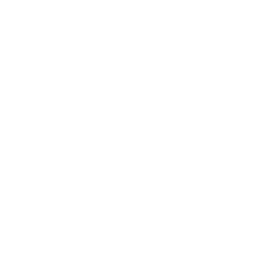
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Kódování nežádoucích příhod v klinickém hodnocení</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutický průmysl / Sledování bezpečnosti léčiv &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Shrnutí

Datové soubory nežádoucích příhod přicházejí s doslovnými preferovanými termíny MedDRA, ale bezpečnostní regulatorní tabulky jsou uspořádány podle systémové orgánové třídy (SOC). Tento příklad vytváří hodnotový formát PROC FORMAT, který mapuje každý preferovaný termín na jeho SOC, a poté tento jediný formát řídí každou navazující tabulaci: křížovou tabulaci PROC FREQ podle SOC a léčebného ramene, rozpad SOC podle závažnosti a souhrn závažných nežádoucích příhod. Protože mapování existuje pouze na jednom místě (ve formátu), přeřazení hodnocení na novou verzi MedDRA znamená úpravu jednoho formátu, nikoli přepsání každého hlášení. ODS OUTPUT zachytává četnosti SOC jako datovou sadu pro navazující přehled signálů.


## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|--------:|
| WORK.AE_RAW | Syntetické záznamy nežádoucích příhod s preferovanými termíny MedDRA | 100 |
| WORK.RANDOMIZATION | Přiřazení léčebného ramene subjektům | 100 |

Prostředí běží bez licence, takže každá vygenerovaná tabulka je omezena na 100 pozorování. Scénář je navržen podle tohoto limitu: 100 nežádoucích příhod vybraných z panelu 12 termínů MedDRA typického pro onkologické hodnocení.


---

In [1]:
/* --------------------------------------------------------
   Generovani syntetickeho datoveho souboru nezadoucich prihod
   Preferovane terminy MedDRA mapovane na kategorie SOC
   -------------------------------------------------------- */
data work.ae_raw;
    CALL streaminit(42);
    POLE pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    DÉLKA aedecod $40 aesev $12;
    OPAKUJ i = 1 TO 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', ZAPSAT(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        KDYŽ pt_idx = 1 PAK aedecod = 'Nevolnost';
        JINAK KDYŽ pt_idx = 2 PAK aedecod = 'Bolest hlavy';
        JINAK KDYŽ pt_idx = 3 PAK aedecod = 'Zvracení';
        JINAK KDYŽ pt_idx = 4 PAK aedecod = 'Průjem';
        JINAK KDYŽ pt_idx = 5 PAK aedecod = 'Kašel';
        JINAK KDYŽ pt_idx = 6 PAK aedecod = 'Únava';
        JINAK KDYŽ pt_idx = 7 PAK aedecod = 'Artralgie';
        JINAK KDYŽ pt_idx = 8 PAK aedecod = 'Horečka';
        JINAK KDYŽ pt_idx = 9 PAK aedecod = 'Bolest břicha';
        JINAK KDYŽ pt_idx = 10 PAK aedecod = 'Neutropenie';
        JINAK KDYŽ pt_idx = 11 PAK aedecod = 'Febrilní neutropenie';
        JINAK aedecod = 'Reakce související s infuzí';
        sev_idx = int(rand('uniform') * 3) + 1;
        KDYŽ pt_idx IN (10, 11) PAK sev_idx = MAX(sev_idx, 2);
        KDYŽ sev_idx = 1 PAK aesev = 'MÍRNÁ';
        JINAK KDYŽ sev_idx = 2 PAK aesev = 'STŘEDNÍ';
        JINAK aesev = 'ZÁVAŽNÁ';
        aeser = ifc(aesev = 'ZÁVAŽNÁ' AND rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        KDYŽ aestdy > 365 PAK aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', ZAPSAT(int(rand('uniform') * 25) + 1, z3.));
        VÝSTUP;
    KONEC;
    ODSTRANIT i pt_idx sev_idx;
SPUSTIT;


NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.85 seconds
  cpu   1.85 seconds


In [2]:
/* --------------------------------------------------------
   Generovani tabulky randomizace subjektu
   -------------------------------------------------------- */
data work.randomization;
    CALL streaminit(43);
    DÉLKA treatment_arm $22;
    OPAKUJ subject_id = 1 TO 800;
        usubjid = cat('ONC-2025-', ZAPSAT(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        KDYŽ arm_idx = 1 PAK treatment_arm = 'EXPERIMENTÁLNÍ';
        JINAK KDYŽ arm_idx = 2 PAK treatment_arm = 'AKTIVNÍ_KOMPARÁTOR';
        JINAK treatment_arm = 'PLACEBO';
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        VÝSTUP;
    KONEC;
    ODSTRANIT arm_idx;
    FORMÁT randomization_date date9.;
SPUSTIT;


NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds


---

                                  Četnost surových preferovaných termínů (nezmapováno)                                  

                                                   The FREQ Procedure

Preferovaný termín                Frequency    Percent
-------------------------------------------------------
Bolest hlavy                             12     12.00
Průjem                                   12     12.00
Horečka                                  11     11.00
Únava                                    11     11.00
Artralgie                                10     10.00
Nevolnost                                10     10.00
Reakce související s infuzí               8      8.00
Kašel                                     7      7.00
Bolest břicha                             5      5.00
Febrilní neutropenie                      5      5.00
Neutropenie                               5      5.00
Zvracení                                  4      4.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


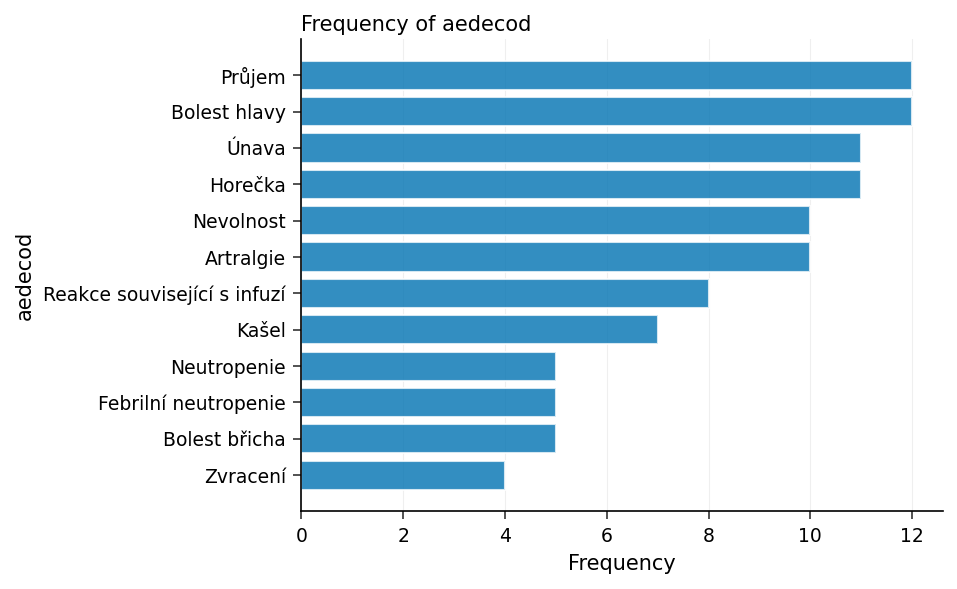

In [3]:
/* --------------------------------------------------------
   Zakladni cetnost preferovanych terminu pred mapovanim na SOC
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=work.ae_raw ORDER=ČETNOSTI;
    TABLES aedecod / nocum;
    ŠTÍTEK aedecod='Preferovaný termín';
    NÁZEV 'Četnost surových preferovaných termínů (nezmapováno)';
SPUSTIT;

---

                                  Četnost surových preferovaných termínů (nezmapováno)                                  




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


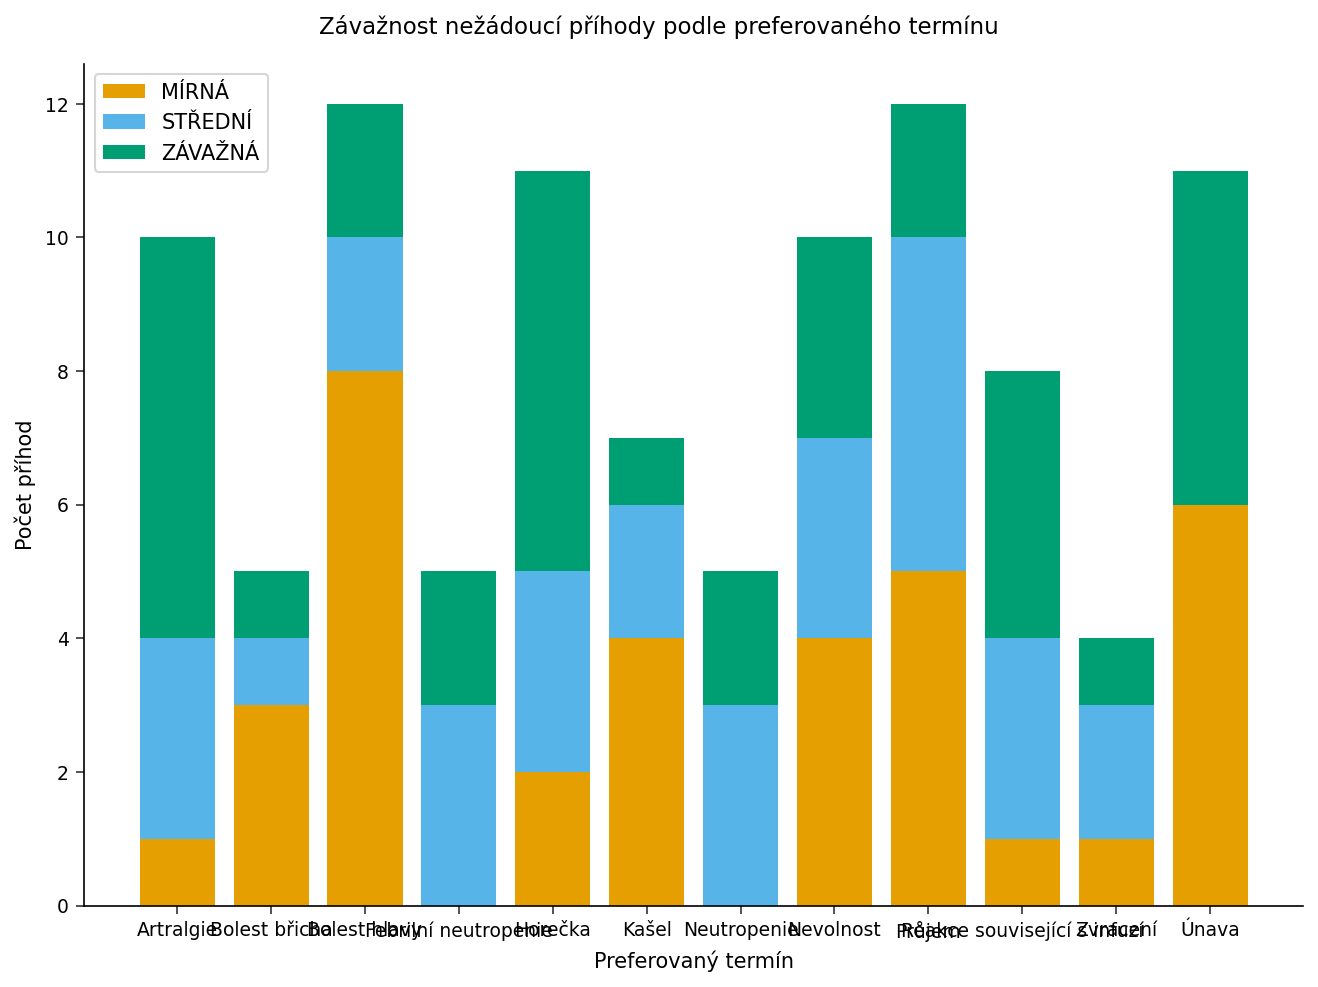

In [4]:
/* --------------------------------------------------------
   Rozlozeni zavaznosti nezadoucich prihod podle preferovaneho terminu
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    XAXIS ŠTÍTEK='Preferovaný termín' fitpolicy=ROTATE;
    YAXIS ŠTÍTEK='Počet příhod';
    NÁZEV 'Závažnost nežádoucí příhody podle preferovaného termínu';
SPUSTIT;

---

In [5]:
/* --------------------------------------------------------
   Definice hodnotoveho formatu preferovany termin MedDRA ->
   systemova organova trida. Format je klicovan na text
   preferovaneho terminu, takze jedno volani PUT() zakoduje
   kterykoli zaznam NP na jeho SOC.
   -------------------------------------------------------- */
PROCEDURA FORMÁT;
    VALUE $pt_to_soc
        'Nevolnost'                    = 'Poruchy trávicího systému'
        'Zvracení'                     = 'Poruchy trávicího systému'
        'Průjem'                       = 'Poruchy trávicího systému'
        'Bolest břicha'                = 'Poruchy trávicího systému'
        'Bolest hlavy'                 = 'Poruchy nervového systému'
        'Únava'                        = 'Celkové poruchy'
        'Horečka'                      = 'Celkové poruchy'
        'Kašel'                        = 'Poruchy dýchacího systému'
        'Artralgie'                    = 'Poruchy svalové a kosterní soustavy'
        'Neutropenie'                  = 'Poruchy krve a lymfatického systému'
        'Febrilní neutropenie'         = 'Poruchy krve a lymfatického systému'
        'Reakce související s infuzí'  = 'Poruchy imunitního systému'
        OTHER                          = 'Nekódováno'
    ;
    VALUE $sev_rank
        'MÍRNÁ'   = '1-Mírná'
        'STŘEDNÍ' = '2-Střední'
        'ZÁVAŽNÁ' = '3-Závažná'
        OTHER     = '9-Neznámá'
    ;
    VALUE $serious_fmt
        'Y' = 'Závažná'
        'N' = 'Nezávažná'
    ;
SPUSTIT;


NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Spojeni zaznamu NP s lecebnym ramenem, nasledne aplikace
   formatu SOC. PUT(aedecod, $pt_to_soc.) je jediny potrebny
   krok mapovani; zavaznost a priznak zavaznosti jsou kodovany stejne.
   -------------------------------------------------------- */
PROCEDURA ŘADIT data=work.ae_raw; PODLE usubjid; SPUSTIT;
PROCEDURA ŘADIT data=work.randomization; PODLE usubjid; SPUSTIT;

data work.ae_coded;
    SLOUČIT work.ae_raw (IN=a)
          work.randomization (IN=b PONECHAT=usubjid treatment_arm);
    PODLE usubjid;
    KDYŽ a;
    soc_class     = ZAPSAT(aedecod, $pt_to_soc.);
    severity_rank = ZAPSAT(aesev,   $sev_rank.);
    serious_flag  = ZAPSAT(aeser,   $serious_fmt.);
SPUSTIT;


NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


                      Výskyt nežádoucích příhod podle systémové orgánové třídy a léčebného ramene                       

                                                   The FREQ Procedure

Table of Systémová orgánová třída by Léčebné rameno

Systémová orgánová třída              |  AKTIVNÍ_KOMPARÁTOR |      EXPERIMENTÁLNÍ |             PLACEBO |                Total
--------------------------------------+---------------------+---------------------+---------------------+---------------------
Celkové poruchy                       |                   1 |                   1 |                   3 |                    5
--------------------------------------+---------------------+---------------------+---------------------+---------------------
Poruchy imunitního systému            |                   0 |                   1 |                   1 |                    2
--------------------------------------+---------------------+---------------------+---------------------+--------------


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


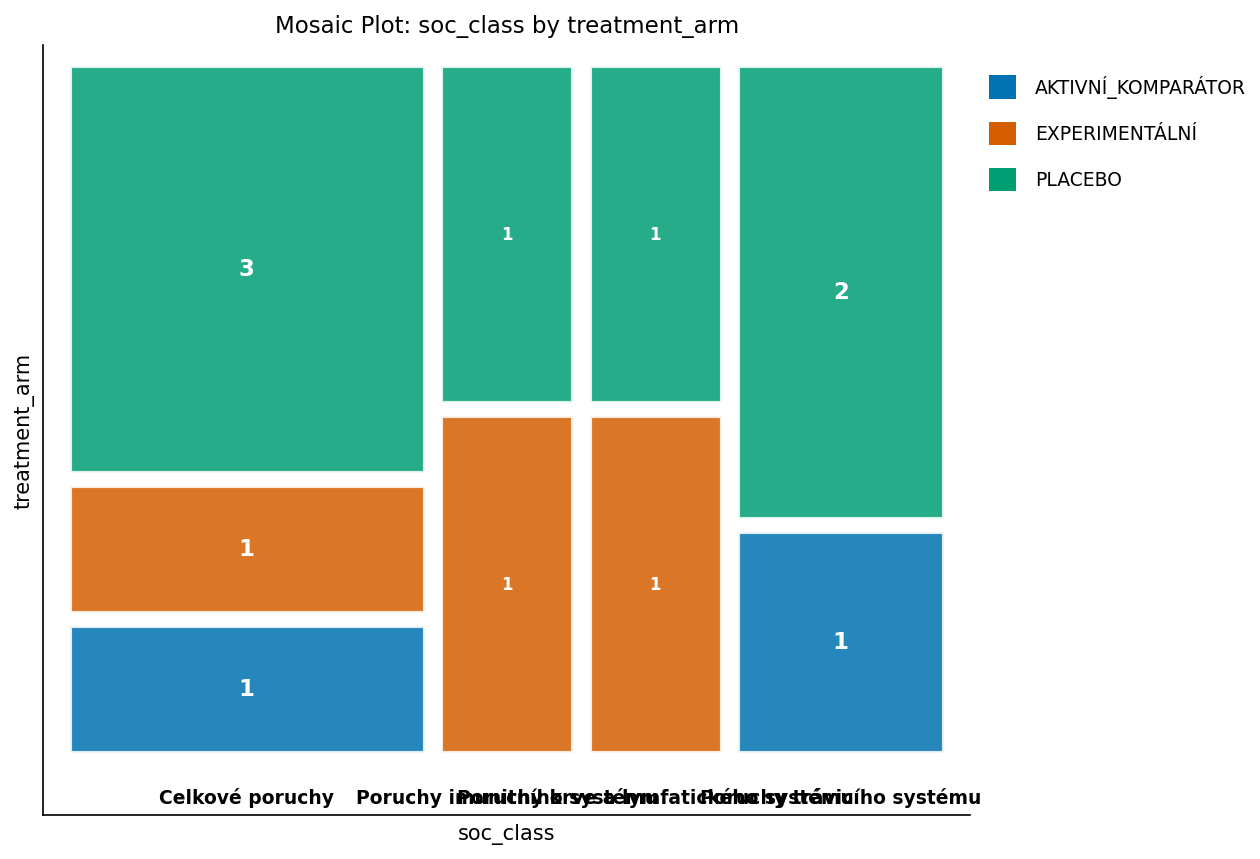

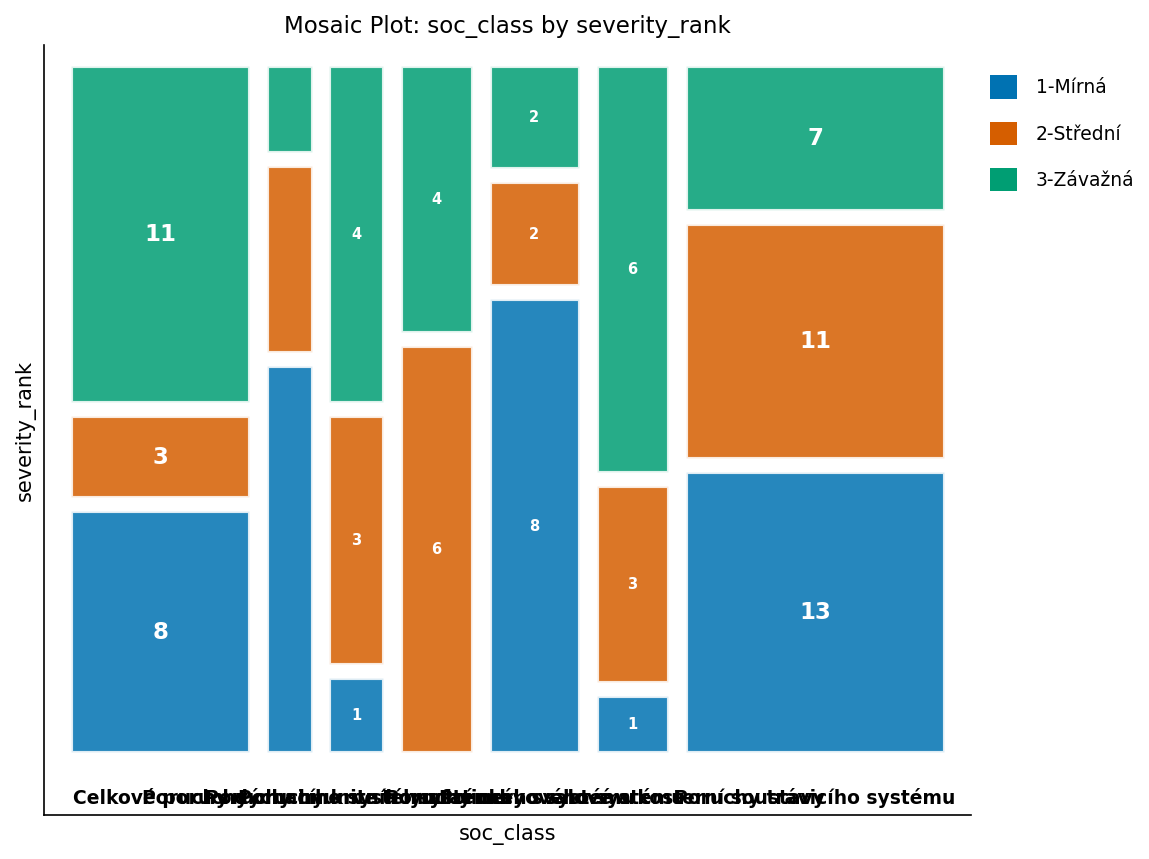

In [7]:
/* --------------------------------------------------------
   Cetnost na urovni SOC podle lecebneho ramene
   ODS OUTPUT zachytava vysledky pro detekci signalu
   -------------------------------------------------------- */
ODS VÝSTUP onewayfreqs=work.soc_freq_table;

PROCEDURA ČETNOSTI data=work.ae_coded ORDER=ČETNOSTI;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    ŠTÍTEK soc_class='Systémová orgánová třída' treatment_arm='Léčebné rameno' severity_rank='Stupeň závažnosti';
    NÁZEV 'Výskyt nežádoucích příhod podle systémové orgánové třídy a léčebného ramene';
SPUSTIT;

ODS VÝSTUP CLOSE;

                                 Závažné nežádoucí příhody podle SOC a léčebného ramene                                 

                                                   The FREQ Procedure

Table of Systémová orgánová třída by Léčebné rameno

Systémová orgánová třída       |  AKTIVNÍ_KOMPARÁTOR |      EXPERIMENTÁLNÍ |             PLACEBO |                Total
-------------------------------+---------------------+---------------------+---------------------+---------------------
Celkové poruchy                |                   1 |                   1 |                   1 |                    3
-------------------------------+---------------------+---------------------+---------------------+---------------------
Poruchy imunitního systému     |                   0 |                   0 |                   1 |                    1
-------------------------------+---------------------+---------------------+---------------------+---------------------
Total                          |  


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


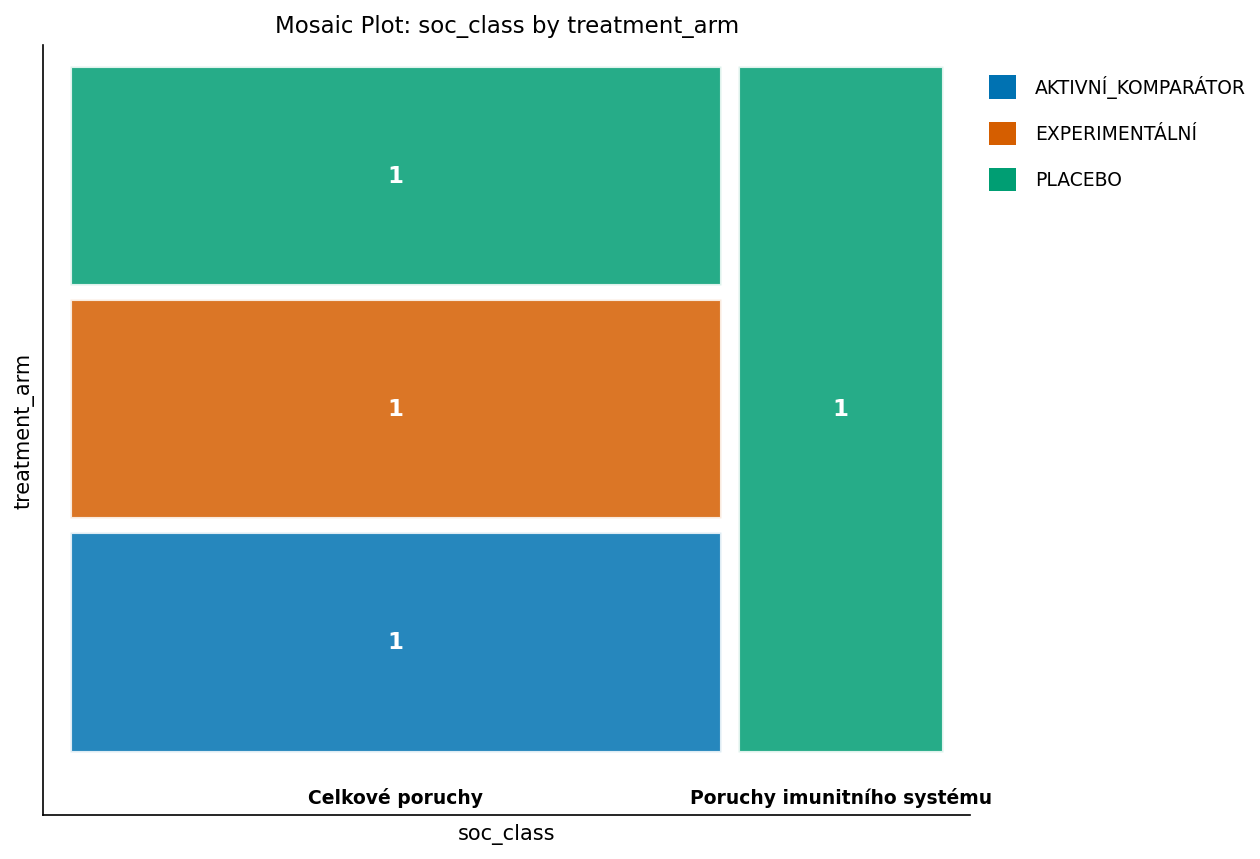

In [8]:
/* --------------------------------------------------------
   Souhrn zavaznych nezadoucich prihod podle SOC pro bezpecnostni narativ
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=work.ae_coded;
    KDE aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    ŠTÍTEK soc_class='Systémová orgánová třída' treatment_arm='Léčebné rameno';
    NÁZEV 'Závažné nežádoucí příhody podle SOC a léčebného ramene';
SPUSTIT;

---

### Interpretace

Jediný hodnotový formát `$pt_to_soc` zakódoval všech 100 nežádoucích příhod z 12 doslovných preferovaných termínů MedDRA do 7 systémových orgánových tříd a tento jediný formát řídil každou tabulku níže, aniž by bylo nutné data přeřazovat.

Podle SOC a závažnosti je **Poruchy trávicího systému** nejčastější třídou s 31 ze 100 příhod (13 mírných, 11 středních, 7 závažných), následuje **Celkové poruchy** s 22 příhodami. Zbylé třídy jsou menší: Poruchy nervového systému (12), Poruchy krve a lymfatického systému (10), Poruchy svalové a kosterní soustavy (10), Poruchy imunitního systému (8) a Poruchy dýchacího systému (7). Napříč všemi příhodami je rozdělení závažnosti 35 mírných, 30 středních a 35 závažných.

Jako závažné byly označeny pouze 4 příhody (`aeser='Y'`): 3 ve třídě Celkové poruchy (jedna na rameno) a 1 ve třídě Poruchy imunitního systému (placebo). Křížová tabulace SOC podle léčebného ramene je sestavena pouze z 12 příhod, jejichž subjekt odpovídal záznamu randomizace, takže počty na úrovni ramene jsou pouze ilustrativní, nikoli statisticky podložené pro srovnání mezi rameny.

Klíčovým poznatkem je mechanismus FORMÁTU, nikoli syntetická čísla: protože mapování preferovaného termínu na SOC existuje výhradně v PROC FORMAT, stejné volání `PUT(aedecod, $pt_to_soc.)` přeřadí celou datovou sadu a aktualizace na novou verzi slovníku MedDRA znamená úpravu jednoho formátu namísto každého hlášení. ODS OUTPUT zachytilo četnosti SOC jako `work.soc_freq_table` pro navazující přehled signálů.


---

In [9]:
/* --------------------------------------------------------
   Export datove sady NP s SOC kodovanim pro bezpecnostni prehled.
   Jediny format $pt_to_soc naplnil soc_class, takze exportovany
   soubor je pripraven pro navazujici analyzu na urovni SOC.
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>